# CCA: Feature extraction and Classification 

### 1: Import　libraries

In [1]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Import evaluation tools
from sklearn.metrics import confusion_matrix, accuracy_score

# Import CCA model
from sklearn.cross_decomposition import CCA

# Make plots look cleaner
sns.set_theme(style="whitegrid")

In [2]:
# Basic settings
N_RUNS = 5
N_CLASSES = 32
N_TRIALS_PER_CLASS = 2
N_CHANNELS = 8
N_SAMPLES = 350
FS = 250

# The first 0.2 s is baseline
BASELINE_SAMPLES = 50

# We simplify 32 classes into 8 frequency labels
freq_list = np.array([8, 9, 10, 11, 12, 13, 14, 15])

# Input folder from notebook 01
INPUT_DIR = "../notebook_outputs/01_load_and_qc"

# Create output folder for notebook 02
OUTPUT_DIR = Path("../notebook_outputs/02_feature_extraction_and_classification")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output folder:", OUTPUT_DIR.resolve())

Output folder: /home/n1shibuya/OpenVEP/notebook_outputs/02_feature_extraction_and_classification


### Load reshaped data & Remove baseline
* 350 Samples → 300 Samples
* Baseline: 0.2 s * 250 sampling rate = 50 samples

In [3]:
# Load 5 runs for each condition
normal_runs = np.array([
    np.load(f"{INPUT_DIR}/normal_run-{run}_reshaped.npy")
    for run in range(1, N_RUNS + 1)
])

redgreen_runs = np.array([
    np.load(f"{INPUT_DIR}/redgreen_run-{run}_reshaped.npy")
    for run in range(1, N_RUNS + 1)
])

blueyellow_runs = np.array([
    np.load(f"{INPUT_DIR}/blueyellow_run-{run}_reshaped.npy")
    for run in range(1, N_RUNS + 1)
])

# Remove baseline part
normal_runs = normal_runs[..., BASELINE_SAMPLES:]
redgreen_runs = redgreen_runs[..., BASELINE_SAMPLES:]
blueyellow_runs = blueyellow_runs[..., BASELINE_SAMPLES:]

print("normal:", normal_runs.shape)
print("redgreen:", redgreen_runs.shape)
print("blueyellow:", blueyellow_runs.shape)

normal: (5, 2, 32, 8, 300)
redgreen: (5, 2, 32, 8, 300)
blueyellow: (5, 2, 32, 8, 300)


### Create the reference signals that CCA compares against the EEG data.

In [4]:
# Create time axis for one trial
n_times = normal_runs.shape[-1]
t = np.arange(n_times) / FS

# Build reference signals for each frequency
reference_signals = {}

for freq in freq_list:
    # Create simple sine and cosine waves
    sin_wave = np.sin(2 * np.pi * freq * t)
    cos_wave = np.cos(2 * np.pi * freq * t)

    # Stack into shape (time, 2)
    reference_signals[freq] = np.column_stack([sin_wave, cos_wave])

print("Reference shape for 8 Hz:", reference_signals[8].shape)

Reference shape for 8 Hz: (300, 2)


### Convert class (0-31) into Frequency label (0-7) for CCA Classification

In [5]:
# Convert class id (0-31) into frequency label (0-7)
# Every 4 classes share the same frequency
freq_label_map = {class_id: class_id // 4 for class_id in range(N_CLASSES)}

# This function converts run data into trials and labels
def make_trials_and_labels(run_data):
    # Lists to collect trials and labels
    X_list = []
    y_list = []

    # Loop through runs, repeats, and classes
    for run_idx in range(run_data.shape[0]):
        for repeat_idx in range(run_data.shape[1]):
            for class_id in range(run_data.shape[2]):
                # One trial has shape (8, 300)
                trial = run_data[run_idx, repeat_idx, class_id]

                # Convert 32-class id into 8-frequency label
                label = freq_label_map[class_id]

                X_list.append(trial)
                y_list.append(label)

    # Convert lists into numpy arrays
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y

# Build trial arrays for each condition
X_normal, y_normal = make_trials_and_labels(normal_runs)
X_redgreen, y_redgreen = make_trials_and_labels(redgreen_runs)
X_blueyellow, y_blueyellow = make_trials_and_labels(blueyellow_runs)

print("X_normal:", X_normal.shape)
print("y_normal:", y_normal.shape)

X_normal: (320, 8, 300)
y_normal: (320,)


### Create function to predict with CCA

In [6]:
# This function predicts one trial using CCA
# It returns both:
# 1. the predicted label
# 2. the best CCA correlation score
def predict_one_trial_cca(trial):
    # EEG trial shape is (8, 300)
    # CCA expects shape (time, features), so transpose it
    X = trial.T

    best_score = -999
    best_label = None

    # Compare this EEG trial with each frequency reference
    for i, freq in enumerate(freq_list):
        Y = reference_signals[freq]

        # Create CCA model with 1 component
        cca = CCA(n_components=1)

        # Fit CCA and transform both signals
        cca.fit(X, Y)
        X_c, Y_c = cca.transform(X, Y)

        # Compute correlation between the transformed signals
        score = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

        # Keep the label with the highest score
        if score > best_score:
            best_score = score
            best_label = i

    return best_label, best_score

In [ ]:
# This function evaluates one condition
# It returns:
# - predicted labels
# - CCA scores for each trial
# - overall accuracy
# - confusion matrix
# - trial-level results table
def evaluate_condition(X, y, condition_name):
    pred_list = []
    score_list = []

    # Predict one trial at a time
    for trial in X:
        pred_label, cca_score = predict_one_trial_cca(trial)
        pred_list.append(pred_label)
        score_list.append(cca_score)

    # Convert lists to arrays
    y_pred = np.array(pred_list)
    cca_scores = np.array(score_list)

    # Compute accuracy
    acc = accuracy_score(y, y_pred)

    # Compute confusion matrix
    cm = confusion_matrix(y, y_pred)

    # Build a trial-level table
    trial_df = pd.DataFrame({
        "condition": condition_name,
        "true_label": y,
        "pred_label": y_pred,
        "cca_score": cca_scores
    })

    return y_pred, cca_scores, acc, cm, trial_df

### Accuracy & Confusion Matrix

In [7]:
# Evaluate each condition
y_pred_normal, cca_normal, acc_normal, cm_normal, trial_df_normal = evaluate_condition(
    X_normal, y_normal, "normal"
)

y_pred_redgreen, cca_redgreen, acc_redgreen, cm_redgreen, trial_df_redgreen = evaluate_condition(
    X_redgreen, y_redgreen, "redgreen"
)

y_pred_blueyellow, cca_blueyellow, acc_blueyellow, cm_blueyellow, trial_df_blueyellow = evaluate_condition(
    X_blueyellow, y_blueyellow, "blueyellow"
)

# Combine all trial-level results into one table
trial_results_df = pd.concat(
    [trial_df_normal, trial_df_redgreen, trial_df_blueyellow],
    ignore_index=True
)

# Make condition-level accuracy table
acc_df = pd.DataFrame({
    "condition": ["normal", "redgreen", "blueyellow"],
    "accuracy": [acc_normal, acc_redgreen, acc_blueyellow]
})

acc_df

,condition,accuracy
0,normal,0.284375
1,redgreen,0.278125
2,blueyellow,0.315625


### Bar Plot for Accuracy & Heatmap for Confusion Matrix

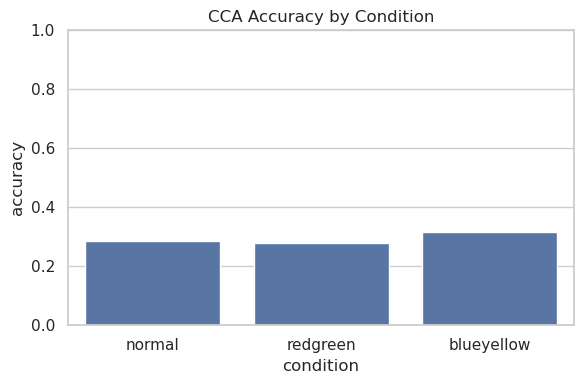

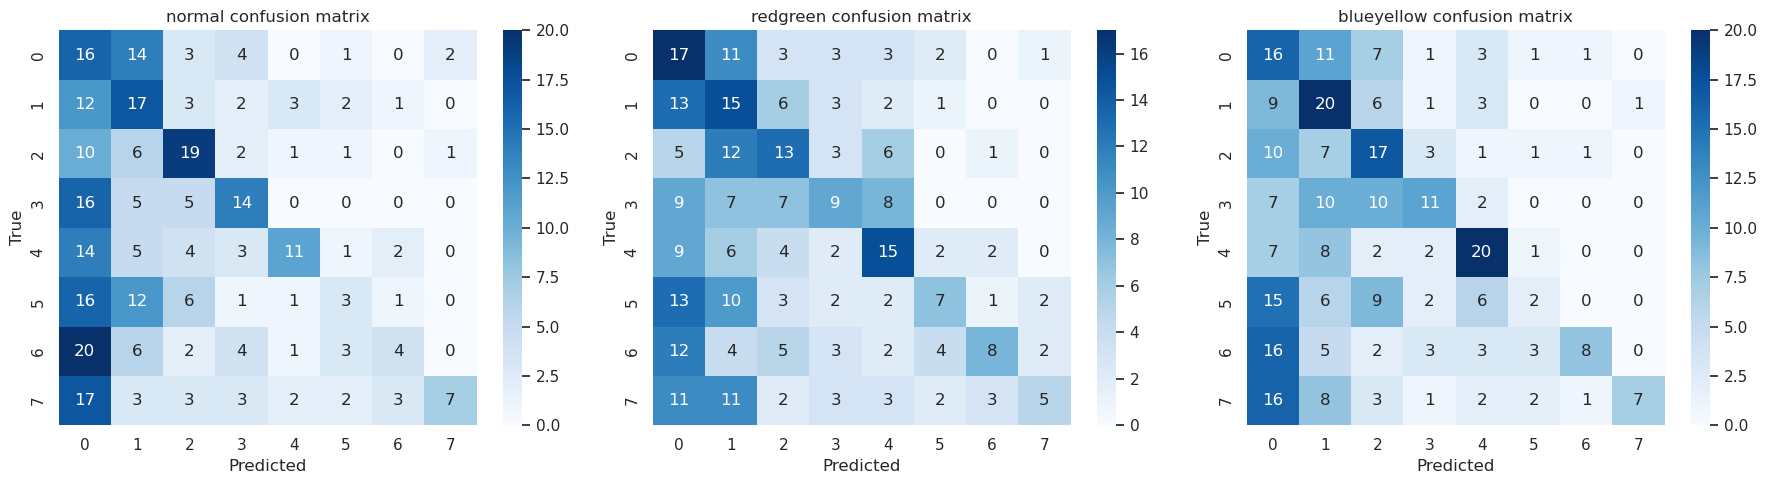

In [8]:
# Plot overall accuracy
plt.figure(figsize=(6, 4))
sns.barplot(data=acc_df, x="condition", y="accuracy")
plt.title("CCA Accuracy by Condition")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_normal, cm_redgreen, cm_blueyellow],
    ["normal", "redgreen", "blueyellow"]
):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{title} confusion matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

In [9]:
acc_df.to_csv(OUTPUT_DIR / "accuracy_by_condition.csv", index=False)